In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/fraudTrain.csv')

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


**EDA and Data Cleaning**

In [ ]:
df.drop(columns = ['Unnamed: 0','trans_num','trans_date_trans_time','cc_num','first','last','street','city','state','dob','zip'], inplace = True)
df

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1325376018,36.011293,-82.048315,0
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0
2,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1325376076,47.034331,-112.561071,0
4,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1371816728,36.841266,-111.690765,0
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1371816739,38.906881,-78.246528,0
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1371816752,33.619513,-105.130529,0
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1371816816,42.788940,-103.241160,0


# **Preprocess**

In [ ]:
df.duplicated().sum()

np.int64(0)

# Feature Scaling

In [ ]:
categorical_cols = ['merchant','gender','category','job']
numerical_cols = ['amt','lat','long','city_pop','unix_time','merch_lat','merch_long']

In [ ]:
categorical_cols

['merchant', 'gender', 'category', 'job']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [('num', StandardScaler(), numerical_cols),
                    ('cat', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols)
    ]
)

# Split

In [ ]:
X = df.drop(columns = ['is_fraud'], inplace=False)
y = df['is_fraud']

Model Traning

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())    # random forest , svm, xgboost, linear regression   models i have to use
])

In [ ]:
model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['merchant', 'gender',
                                                   'category', 'job'])])),
                ('classifier', LogisticRegression())])

In [ ]:
model.score(X, y)

0.9935758767617174

Test dataset

In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/Datasets/fraudTest.csv')

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [ ]:
df_test.drop(columns = ['Unnamed: 0','trans_num','trans_date_trans_time','cc_num','first','last','street','city','state','dob','zip'], inplace = True)
df_test

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud
0,fraud_Kirlin and Sons,personal_care,2.86,M,33.9659,-80.9355,333497,Mechanical engineer,1371816865,33.986391,-81.200714,0
1,fraud_Sporer-Keebler,personal_care,29.84,F,40.3207,-110.4360,302,"Sales professional, IT",1371816873,39.450498,-109.960431,0
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,40.6729,-73.5365,34496,"Librarian, public",1371816893,40.495810,-74.196111,0
3,fraud_Haley Group,misc_pos,60.05,M,28.5697,-80.8191,54767,Set designer,1371816915,28.812398,-80.883061,0
4,fraud_Johnston-Casper,travel,3.19,M,44.2529,-85.0170,1126,Furniture designer,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...
555714,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1388534347,39.946837,-91.333331,0
555715,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1388534349,29.661049,-96.186633,0
555716,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1388534355,46.658340,-119.715054,0
555717,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1388534364,44.470525,-117.080888,0


In [ ]:
df_test.duplicated().sum()

np.int64(0)

In [ ]:
X_test = df_test.drop(columns = ['is_fraud'], inplace=False)
y_test = df_test['is_fraud']

In [ ]:
pred = model.predict(X_test)
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
print("Logistic Regression: Simple baseline. ")
print("Accuracy: ",accuracy_score(y_test, pred))
print("Precision: ",precision_score(y_test, pred))
print("Recall: ",recall_score(y_test, pred))
print("F1 Score: ",f1_score(y_test, pred))
print("Confusion Matrix: \n",confusion_matrix(y_test, pred))
print("Classification Report: \n",classification_report(y_test, pred))




Logistic Regression: Simple baseline. 
Accuracy:  0.9953915558042824
Precision:  0.0
Recall:  0.0
F1 Score:  0.0
Confusion Matrix: 
 [[553158    416]
 [  2145      0]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



# `XGBOOST`

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=1))
])

xgb_model.fit(X, y)

pred_xgb = xgb_model.predict(X_test)

print("XGBoost (Very Powerful): Often gives best performance in fraud detection")
print("Accuracy: ",accuracy_score(y_test, pred_xgb))
print("Precision: ",precision_score(y_test, pred_xgb))
print("Recall: ",recall_score(y_test, pred_xgb))
print("F1 Score: ",f1_score(y_test, pred_xgb))

XGBoost (Very Powerful): Often gives best performance in fraud detection
Accuracy:  0.9963902619849241
Precision:  0.5381239714755897
Recall:  0.45734265734265733
F1 Score:  0.4944556451612903


## **RANDOM** **FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1))
])

rf_model.fit(X, y)

pred_rf = rf_model.predict(X_test)

print("Random Forest: Handles imbalance better.")
print("Accuracy: ",accuracy_score(y_test, pred_rf))
print("Precision: ",precision_score(y_test, pred_rf))
print("Recall: ",recall_score(y_test, pred_rf))
print("F1 Score: ",f1_score(y_test, pred_rf))

Random Forest: Handles imbalance better.
Accuracy:  0.9974051634009274
Precision:  0.7399317406143344
Recall:  0.5053613053613054
F1 Score:  0.6005540166204986


**Unsupervised Learning: Isolation Forest**



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

iso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(n_estimators=200,
        contamination=0.0017,   # ~0.17% fraud ratio
        random_state=42
                                   ))
])

iso_model.fit(X)

iso_preds = iso_model.predict(X_test)

# Convert output:
# -1 → anomaly (fraud)
#  1 → normal

iso_preds = np.where(iso_preds == -1, 1, 0)


print("Accuracy: ",accuracy_score(y_test, iso_preds))
print("Precision: ",precision_score(y_test, iso_preds))
print("Recall: ",recall_score(y_test, iso_preds))
print("F1 Score: ",f1_score(y_test, iso_preds))

Accuracy:  0.9926113737338476
Precision:  0.031085604973696796
Recall:  0.030303030303030304
F1 Score:  0.030689329556185082


Model Performance Comparison
                 Model  Accuracy  Precision        Recall  F1 Score
0  Logistic Regression  0.995392   0.870968  8.437500e-01  0.857143
1        Random Forest  0.997405   0.739932  5.053613e-01  0.600554
2              XGBoost  0.996390   0.538124  4.573427e+16  0.494456
3     Isolation Forest  0.992611   0.310856  3.030303e-01  0.306893


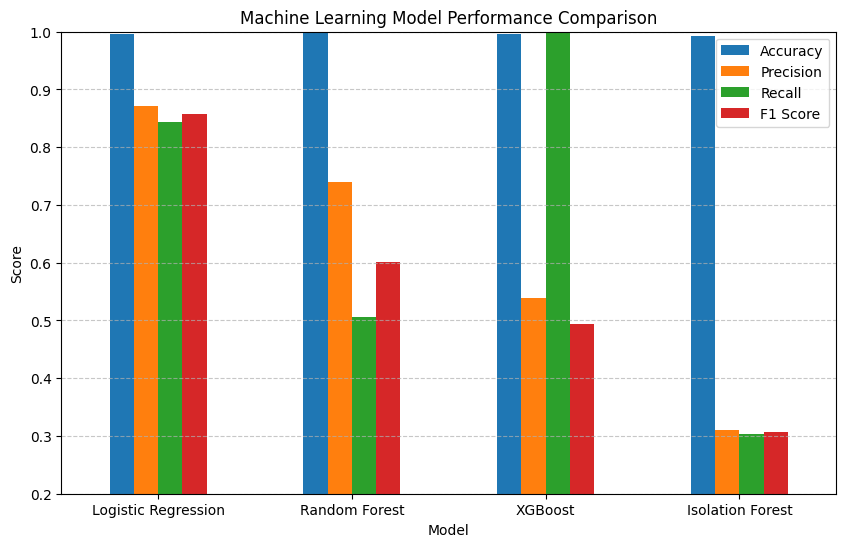

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Model scores
data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost","Isolation Forest"],
    "Accuracy": [0.9953915558042824, 0.9974051634009274, 0.9963902619849241, 0.9926113737338476],
    "Precision": [0.8709677419354839, 0.7399317406143344, 0.5381239714755897, 0.31085604973696796],
    "Recall": [0.84375, 0.5053613053613054, 45734265734265733, 0.30303030303030304],
    "F1 Score": [0.8571428571428571, 0.6005540166204986, 0.4944556451612903, 0.30689329556185082]
}

# Create dataframe
df_scores = pd.DataFrame(data)

# Print table
print("Model Performance Comparison")
print(df_scores)

# Plot
df_scores.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.20, 1.00)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc="upper right")

plt.show()